# 📈 Modelos Lineales — Proyecto de Minería de Datos
## Dataset: Divorcios en Guatemala (`mat_full.csv`)

Este notebook implementa modelos lineales con sklearn:
1. **Regresión** (LinearRegression, Ridge, Lasso)
2. **Regresión Logística multiclase — 5 clases** (`CAT_DIFF`)
3. **Regresión Logística multiclase — 3 clases** (`CAT3`)

> Los modelos lineales son altamente interpretables. Sus coeficientes indican directamente el impacto de cada variable en la predicción. A diferencia de los árboles, **requieren escalado** porque son sensibles a la magnitud de las features.

## 🔹 PASO 1: Importación de Librerías

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid')
print("Librerías cargadas correctamente ✓")

Librerías cargadas correctamente ✓


## 🔹 PASO 2: Carga del Dataset

In [30]:
df = pd.read_csv('mat_full.csv')

for col in ['EDADHOM', 'EDADMUJ', 'AÑOREG']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print(f"Shape: {df.shape}")
df.head()

Shape: (752264, 15)


,AÑOREG,CLAUNI,DEPOCU,DEPREG,DIAOCU,EDADHOM,EDADMUJ,ESCHOM,ESCMUJ,MESOCU,MESREG,MUPOCU,MUPREG,NACHOM,NACMUJ
0,2011.0,Comunidad de gananciales,Guatemala,Guatemala,20.0,27.0,32.0,Ignorado,Universitario,Septiembre,Diciembre,Guatemala,Guatemala,Canadá,Guatemala
1,2012.0,Separación absoluta,Guatemala,Guatemala,12.0,29.0,31.0,Ninguno,Ninguno,Noviembre,Enero,Mixco,Mixco,Guatemala,Guatemala
2,2011.0,Comunidad de gananciales,Totonicapan,Totonicapan,12.0,21.0,17.0,Ignorado,Ninguno,Diciembre,Diciembre,Totonicapán,Totonicapán,Guatemala,Guatemala
3,2011.0,Separación absoluta,Guatemala,Guatemala,25.0,58.0,53.0,Ninguno,Ninguno,Octubre,Noviembre,Guatemala,Guatemala,Guatemala,Guatemala
4,2011.0,Comunidad de gananciales,Guatemala,Guatemala,2.0,31.0,24.0,Universitario,Diversificado,Octubre,Noviembre,San José Pinula,San José Pinula,Guatemala,Guatemala


In [31]:
print(df.info())
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 752264 entries, 0 to 752263
Data columns (total 15 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   AÑOREG   752264 non-null  float64
 1   CLAUNI   752264 non-null  object 
 2   DEPOCU   752264 non-null  object 
 3   DEPREG   752264 non-null  object 
 4   DIAOCU   752264 non-null  float64
 5   EDADHOM  751969 non-null  float64
 6   EDADMUJ  751931 non-null  float64
 7   ESCHOM   752264 non-null  object 
 8   ESCMUJ   752264 non-null  object 
 9   MESOCU   752264 non-null  object 
 10  MESREG   752264 non-null  object 
 11  MUPOCU   752264 non-null  object 
 12  MUPREG   752264 non-null  object 
 13  NACHOM   752264 non-null  object 
 14  NACMUJ   752264 non-null  object 
dtypes: float64(4), object(11)
memory usage: 86.1+ MB
None


,AÑOREG,DIAOCU,EDADHOM,EDADMUJ
count,752264.000000,752264.000000,751969.000000,751931.000000
mean,2015.404325,16.034647,29.364554,26.366032
std,2.844226,8.645327,11.322095,9.984820
min,2011.000000,1.000000,12.000000,10.000000
25%,2013.000000,9.000000,22.000000,20.000000
50%,2015.000000,16.000000,26.000000,23.000000
75%,2018.000000,23.000000,32.000000,29.000000
max,2021.000000,31.000000,99.000000,99.000000


## 🔹 PASO 3: Preprocesamiento Global

### ⚠️ StandardScaler — por qué es obligatorio en modelos lineales

La regresión lineal minimiza la suma de cuadrados de residuos. Si las variables tienen magnitudes muy distintas (ej: `AÑOREG` en miles vs. un dummy binario), las variables de mayor escala dominarán los coeficientes artificialmente.

**Ridge y Lasso** aplican regularización (penalización sobre los coeficientes). Sin escalar, la penalización favorece incorrectamente variables en escalas pequeñas.

> **Regla:** Siempre ajustar `StandardScaler` **solo sobre el train set** y aplicarlo al test set. Esto evita *data leakage*.

In [32]:
# 1. Variable objetivo
df['DIFF_EDAD'] = df['EDADHOM'] - df['EDADMUJ']

# 2. Eliminar nulos
df = df.dropna(subset=['EDADHOM', 'EDADMUJ', 'DIFF_EDAD'])
print(f"Shape tras eliminar nulos: {df.shape}")

# 3. Variables de clasificación
bins5 = [-np.inf, 0, 2, 3, 5, np.inf]
labels5 = ['Mujer mayor', '0-2 años', '2-3 años', '3-5 años', '> 5 años']
df['CAT_DIFF'] = pd.cut(df['DIFF_EDAD'], bins=bins5, labels=labels5)

bins3 = [-np.inf, -1, 5, np.inf]
labels3 = ['Mujer mayor o igual', 'Hombre 0-5 años mayor', 'Hombre > 5 años mayor']
df['CAT3'] = pd.cut(df['DIFF_EDAD'], bins=bins3, labels=labels3)

# 4. One-Hot Encoding
cat_cols = ['DEPREG', 'MESOCU', 'NACHOM', 'NACMUJ', 'ESCHOM', 'ESCMUJ']
cat_cols = [c for c in cat_cols if c in df.columns]
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

print(f"Nulos restantes: {df_encoded.isnull().sum().sum()}")
print(f"Shape final: {df_encoded.shape}")
print("Preprocesamiento completado ✓")

Shape tras eliminar nulos: (751741, 16)
Nulos restantes: 0
Shape final: (751741, 268)
Preprocesamiento completado ✓


## 🔹 PASO 4: EDA

> **Nota:** Los modelos lineales asumen una relación **lineal** entre las features y la variable objetivo. Para regresión logística, la relación es lineal en el espacio de **log-odds** (logit), no en las probabilidades directamente.

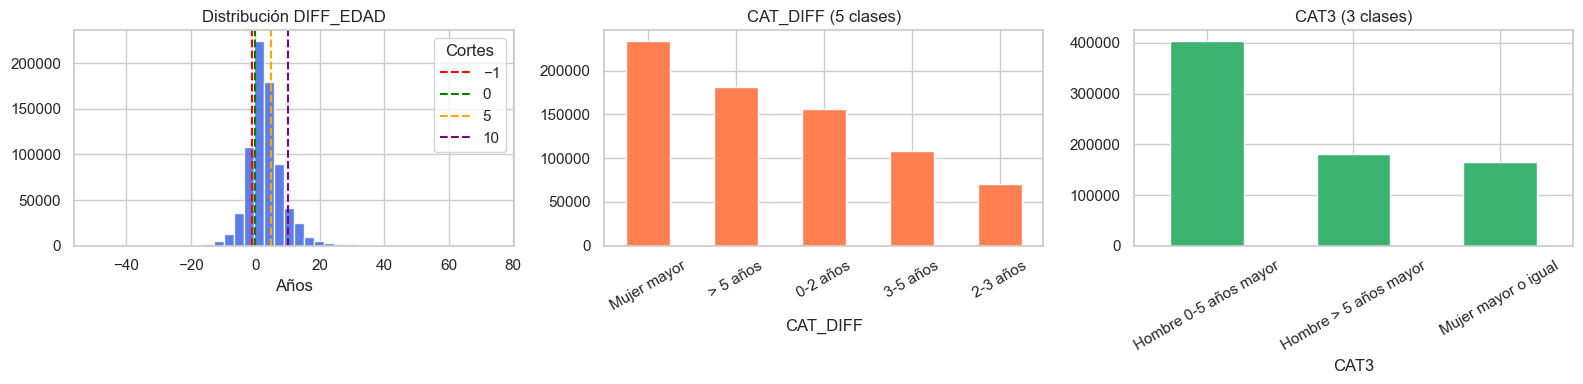

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(df['DIFF_EDAD'], bins=40, color='royalblue', edgecolor='white', alpha=0.85)
for val, color, lbl in [(-1,'red','−1'), (0,'green','0'), (5,'orange','5'), (10,'purple','10')]:
    axes[0].axvline(val, color=color, linestyle='--', linewidth=1.5, label=lbl)
axes[0].set_title('Distribución DIFF_EDAD')
axes[0].set_xlabel('Años')
axes[0].legend(title='Cortes')

df['CAT_DIFF'].value_counts().plot(kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('CAT_DIFF (5 clases)')
axes[1].tick_params(axis='x', rotation=30)

df['CAT3'].value_counts().plot(kind='bar', ax=axes[2], color='mediumseagreen', edgecolor='white')
axes[2].set_title('CAT3 (3 clases)')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('rl_eda.png', bbox_inches='tight')
plt.show()

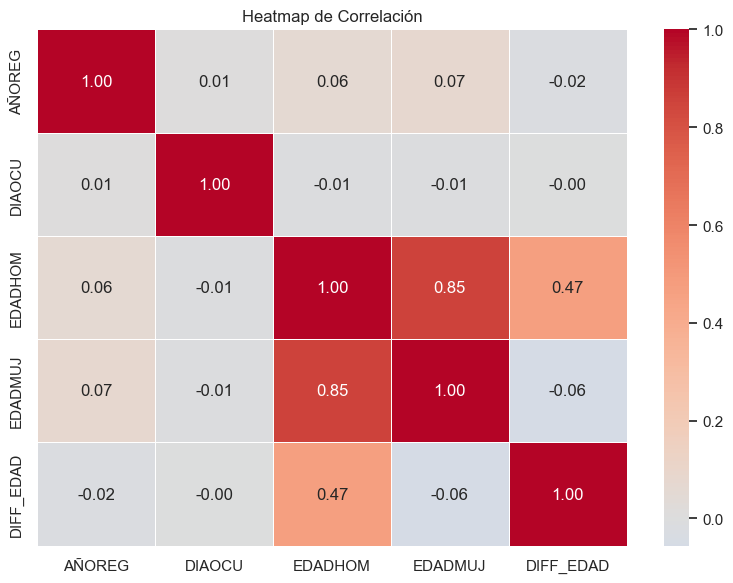

In [34]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[num_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Heatmap de Correlación')
plt.tight_layout()
plt.show()

---
## 📈 BLOQUE 1: Regresión (LinearRegression, Ridge, Lasso)

### Fundamento teórico

| Modelo | Penalización | Efecto |
|---|---|---|
| **OLS** (LinearRegression) | Ninguna | Mínimos cuadrados puros. Máxima varianza de coeficientes. |
| **Ridge** (L2) | `α * Σβ²` | Encoge coeficientes hacia cero. No los elimina. |
| **Lasso** (L1) | `α * Σ|β|` | Puede fijar coeficientes exactamente en cero → selección automática de variables. |

`alpha` controla la fuerza de la regularización. Mayor `alpha` → más encogimiento → modelo más simple.

In [35]:
# Preparar features
exclude = ['DIFF_EDAD', 'CAT_DIFF', 'CAT3', 'EDADHOM', 'EDADMUJ', 'CLAUNI',
           'DEPOCU', 'MUPOCU', 'MUPREG', 'MESREG']
features = [c for c in df_encoded.columns if c not in exclude
            and df_encoded[c].dtype in [np.float64, np.int64, np.uint8, bool]]

X = df_encoded[features].fillna(0)
y_reg = df_encoded['DIFF_EDAD']

X_train, X_test, y_train, y_test = train_test_split(X, y_reg, test_size=0.2, random_state=42)

# ⚠️ Escalar DESPUÉS del split, ajustando solo con train
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train: {X_train_sc.shape} | Test: {X_test_sc.shape}")
print("Escalado aplicado correctamente ✓")

Train: (601392, 258) | Test: (150349, 258)
Escalado aplicado correctamente ✓


In [36]:
models_reg = {
    'LinearRegression': LinearRegression(),
    'Ridge (α=1.0)':    Ridge(alpha=1.0),
    'Lasso (α=0.1)':    Lasso(alpha=0.1, max_iter=5000),
}

results_reg = []
fitted_reg = {}

for name, model in models_reg.items():
    model.fit(X_train_sc, y_train)
    y_pred = model.predict(X_test_sc)

    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)

    results_reg.append({'Modelo': name, 'MAE': mae, 'RMSE': rmse, 'R²': r2})
    fitted_reg[name] = model
    print(f"{name}: MAE={mae:.3f}, RMSE={rmse:.3f}, R²={r2:.4f}")

df_results_reg = pd.DataFrame(results_reg)
print("\n", df_results_reg.to_string(index=False))

LinearRegression: MAE=3.989, RMSE=5.832, R²=0.0321
Ridge (α=1.0): MAE=3.989, RMSE=5.832, R²=0.0321
Lasso (α=0.1): MAE=4.005, RMSE=5.861, R²=0.0222

           Modelo      MAE     RMSE       R²
LinearRegression 3.989286 5.831651 0.032059
   Ridge (α=1.0) 3.989285 5.831650 0.032059
   Lasso (α=0.1) 4.005158 5.861273 0.022201


### Interpretación de coeficientes

Cada coeficiente en un modelo escalado indica cuántos años cambia `DIFF_EDAD` al aumentar la feature en 1 desviación estándar, manteniendo el resto constante.

- **Coeficiente positivo:** esa variable se asocia con mayor diferencia de edades (hombre más mayor).
- **Coeficiente negativo:** se asocia con menor diferencia o con que la mujer sea mayor.
- **Coeficiente = 0 (Lasso):** la variable fue eliminada automáticamente.

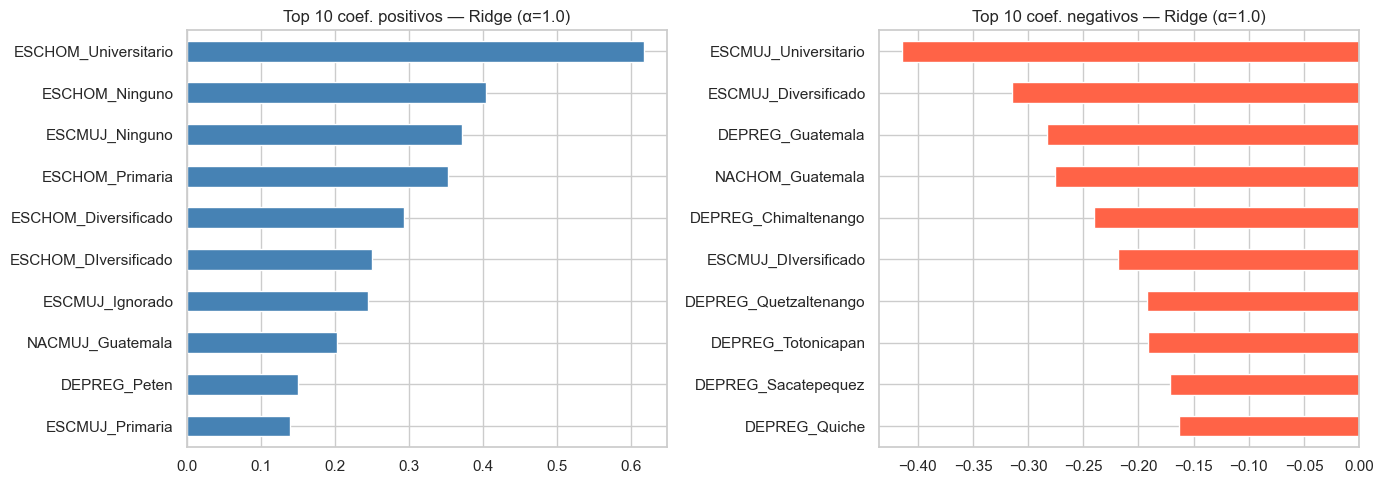

In [37]:
# Coeficientes del mejor modelo
best_name = df_results_reg.loc[df_results_reg['R²'].idxmax(), 'Modelo']
best_model_reg = fitted_reg[best_name]

coefs = pd.Series(best_model_reg.coef_, index=X.columns)
top_pos = coefs.nlargest(10)
top_neg = coefs.nsmallest(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
top_pos.sort_values().plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title(f'Top 10 coef. positivos — {best_name}')
top_neg.sort_values(ascending=False).plot(kind='barh', ax=axes[1], color='tomato', edgecolor='white')
axes[1].set_title(f'Top 10 coef. negativos — {best_name}')

plt.tight_layout()
plt.savefig('rl_coeficientes_reg.png', bbox_inches='tight')
plt.show()

In [38]:
# Variables eliminadas por Lasso
lasso_model = fitted_reg['Lasso (α=0.1)']
lasso_coefs = pd.Series(lasso_model.coef_, index=X.columns)
zeros = (lasso_coefs == 0).sum()
print(f"Variables eliminadas por Lasso: {zeros} de {len(lasso_coefs)} ({zeros/len(lasso_coefs)*100:.1f}%)")
print(f"\nTop variables NO eliminadas por Lasso:")
print(lasso_coefs[lasso_coefs != 0].abs().nlargest(10).to_string())

Variables eliminadas por Lasso: 239 de 258 (92.6%)

Top variables NO eliminadas por Lasso:
ESCHOM_Universitario    0.303186
ESCMUJ_Diversificado    0.264793
ESCMUJ_Universitario    0.256089
ESCMUJ_Ninguno          0.240812
ESCHOM_Ninguno          0.177041
DEPREG_Peten            0.128744
ESCMUJ_DIversificado    0.099941
DEPREG_Jutiapa          0.099091
ESCMUJ_Ignorado         0.093510
ESCHOM_Primaria         0.052743


---
## 📊 BLOQUE 2: Regresión Logística — 5 Clases (`CAT_DIFF`)

### Fundamento teórico

La regresión logística multiclase con `multi_class='multinomial'` modela **todas las clases simultáneamente** usando la función **softmax**:

$$P(y=k|x) = \frac{e^{\beta_k^T x}}{\sum_j e^{\beta_j^T x}}$$

Esto es preferible al enfoque OVR (One-vs-Rest) para clases mutuamente excluyentes.

**Parámetro `C`:** Inverso de la regularización (C = 1/α).
- C pequeño (0.1) → más regularización → coeficientes más pequeños.
- C grande (10) → menos regularización → riesgo de overfitting.

### ⚠️ Desbalance de clases
Se usa `class_weight='balanced'` para compensar la subrepresentación de la clase `2-3 años`.

In [39]:
y5 = df_encoded['CAT_DIFF'].astype(str)
X5_train, X5_test, y5_train, y5_test = train_test_split(
    X, y5, test_size=0.2, random_state=42, stratify=y5)

scaler5 = StandardScaler()
X5_train_sc = scaler5.fit_transform(X5_train)
X5_test_sc  = scaler5.transform(X5_test)

print(f"Train: {X5_train_sc.shape} | Test: {X5_test_sc.shape}")
print("Escalado 5 clases aplicado ✓")

Train: (601392, 258) | Test: (150349, 258)
Escalado 5 clases aplicado ✓


In [40]:
C_values = [0.1, 1.0, 10.0]
results_5 = []
models_5 = []

for C in C_values:
    model = LogisticRegression(
        C=C,
        penalty='l2',
        solver='lbfgs',
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    )
    model.fit(X5_train_sc, y5_train)
    y_pred = model.predict(X5_test_sc)

    acc  = accuracy_score(y5_test, y_pred)
    prec = precision_score(y5_test, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y5_test, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y5_test, y_pred, average='weighted', zero_division=0)

    results_5.append({'C': C, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-weighted': f1})
    models_5.append(model)
    print(f"C={C}: Acc={acc:.3f}, Precision={prec:.3f}, Recall={rec:.3f}, F1={f1:.3f}")

df_results_5 = pd.DataFrame(results_5)
print("\n", df_results_5.to_string(index=False))

C=0.1: Acc=0.295, Precision=0.281, Recall=0.295, F1=0.283
C=1.0: Acc=0.295, Precision=0.281, Recall=0.295, F1=0.283
C=10.0: Acc=0.295, Precision=0.281, Recall=0.295, F1=0.283

    C  Accuracy  Precision   Recall  F1-weighted
 0.1  0.295153   0.280640 0.295153     0.282569
 1.0  0.295173   0.280604 0.295173     0.282544
10.0  0.295180   0.280609 0.295180     0.282549


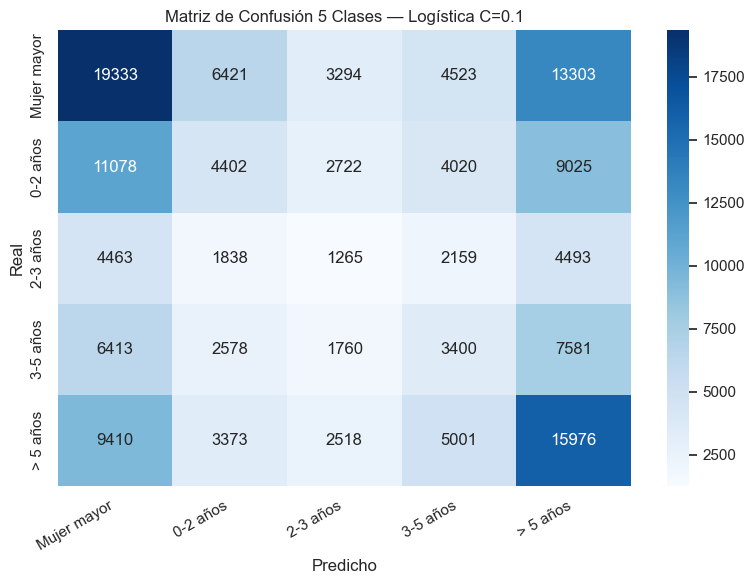

              precision    recall  f1-score   support

    0-2 años       0.24      0.14      0.18     31247
    2-3 años       0.11      0.09      0.10     14218
    3-5 años       0.18      0.16      0.17     21732
    > 5 años       0.32      0.44      0.37     36278
 Mujer mayor       0.38      0.41      0.40     46874

    accuracy                           0.30    150349
   macro avg       0.24      0.25      0.24    150349
weighted avg       0.28      0.30      0.28    150349



In [41]:
best_idx5 = df_results_5['F1-weighted'].idxmax()
best_model5 = models_5[best_idx5]
best_C5 = C_values[best_idx5]

y_pred5 = best_model5.predict(X5_test_sc)
labels5_list = ['Mujer mayor', '0-2 años', '2-3 años', '3-5 años', '> 5 años']
cm5 = confusion_matrix(y5_test, y_pred5, labels=labels5_list)

plt.figure(figsize=(8, 6))
sns.heatmap(cm5, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels5_list, yticklabels=labels5_list)
plt.title(f'Matriz de Confusión 5 Clases — Logística C={best_C5}')
plt.ylabel('Real'); plt.xlabel('Predicho')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('rl_confusion_5clases.png', bbox_inches='tight')
plt.show()

print(classification_report(y5_test, y_pred5, zero_division=0))

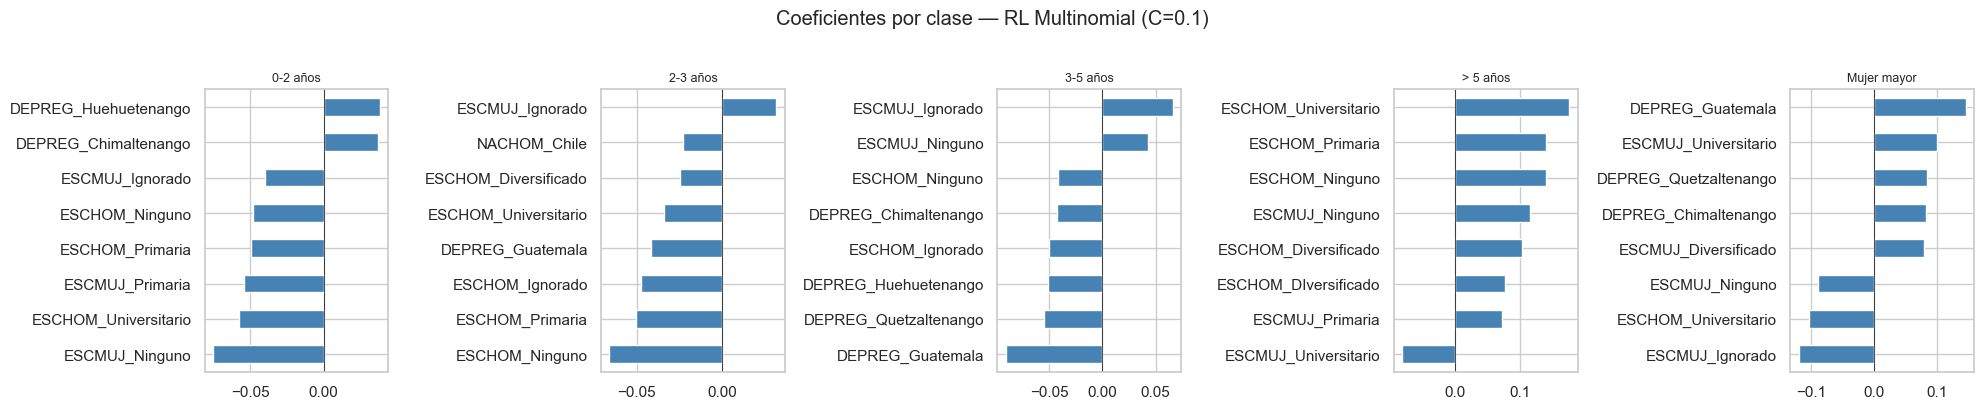

In [42]:
# Coeficientes por clase
coef_df5 = pd.DataFrame(best_model5.coef_, index=best_model5.classes_, columns=X.columns)

fig, axes = plt.subplots(1, len(labels5_list), figsize=(20, 4), sharey=False)
for i, (label, ax) in enumerate(zip(best_model5.classes_, axes)):
    top = coef_df5.loc[label].abs().nlargest(8).index
    coef_df5.loc[label, top].sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f'{label}', fontsize=9)
    ax.axvline(0, color='black', linewidth=0.5)

plt.suptitle(f'Coeficientes por clase — RL Multinomial (C={best_C5})', y=1.02)
plt.tight_layout()
plt.savefig('rl_coef_5clases.png', bbox_inches='tight')
plt.show()

---
## 📊 BLOQUE 3: Regresión Logística — 3 Clases (`CAT3`)

### ✔️ Dataset más balanceado

Con 3 clases más equilibradas, la regresión logística tiene mejor desempeño. Se comparan:
- **L2 (C=1.0):** Regularización estándar.
- **L2 (C=0.1):** Regularización más fuerte.
- **L1 (liblinear):** Selección automática de variables (Lasso logístico).

In [43]:
y3 = df_encoded['CAT3'].astype(str)
X3_train, X3_test, y3_train, y3_test = train_test_split(
    X, y3, test_size=0.2, random_state=42, stratify=y3)

scaler3 = StandardScaler()
X3_train_sc = scaler3.fit_transform(X3_train)
X3_test_sc  = scaler3.transform(X3_test)

print(f"Train: {X3_train_sc.shape} | Test: {X3_test_sc.shape}")

Train: (601392, 258) | Test: (150349, 258)


In [44]:
configs_3 = [
    {'penalty': 'l2', 'C': 1.0,  'solver': 'lbfgs',     'label': 'L2 C=1.0 (multinomial)'},
    {'penalty': 'l2', 'C': 0.1,  'solver': 'lbfgs',     'label': 'L2 C=0.1 (más regularización)'},
    {'penalty': 'l1', 'C': 1.0,  'solver': 'saga',      'label': 'L1 C=1.0 (selección vars)'},
]

results_3 = []
models_3 = []

for cfg in configs_3:
    model = LogisticRegression(
        penalty=cfg['penalty'],
        C=cfg['C'],
        solver=cfg['solver'],
        max_iter=2000,  # Aumentado para L1 con saga
        random_state=42
    )
    model.fit(X3_train_sc, y3_train)
    y_pred = model.predict(X3_test_sc)

    acc  = accuracy_score(y3_test, y_pred)
    prec = precision_score(y3_test, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y3_test, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y3_test, y_pred, average='weighted', zero_division=0)

    results_3.append({'Modelo': cfg['label'], 'Accuracy': acc, 'Precision': prec,
                      'Recall': rec, 'F1-weighted': f1})
    models_3.append(model)
    print(f"{cfg['label']}: Acc={acc:.3f}, F1={f1:.3f}")

df_results_3 = pd.DataFrame(results_3)
print("\n", df_results_3.to_string(index=False))

L2 C=1.0 (multinomial): Acc=0.538, F1=0.386
L2 C=0.1 (más regularización): Acc=0.538, F1=0.386
L1 C=1.0 (selección vars): Acc=0.538, F1=0.386

                        Modelo  Accuracy  Precision   Recall  F1-weighted
       L2 C=1.0 (multinomial)  0.537736   0.458357 0.537736     0.385831
L2 C=0.1 (más regularización)  0.537736   0.458357 0.537736     0.385831
    L1 C=1.0 (selección vars)  0.537742   0.458835 0.537742     0.385857


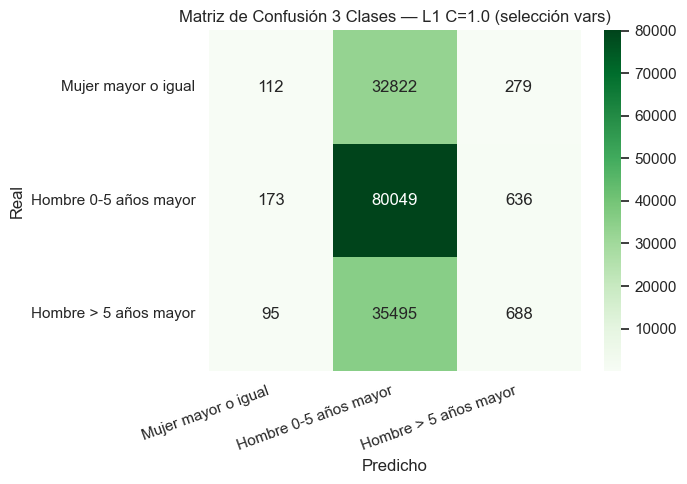

                       precision    recall  f1-score   support

Hombre 0-5 años mayor       0.54      0.99      0.70     80858
Hombre > 5 años mayor       0.43      0.02      0.04     36278
  Mujer mayor o igual       0.29      0.00      0.01     33213

             accuracy                           0.54    150349
            macro avg       0.42      0.34      0.25    150349
         weighted avg       0.46      0.54      0.39    150349



In [45]:
best_idx3 = df_results_3['F1-weighted'].idxmax()
best_model3 = models_3[best_idx3]
best_label3 = configs_3[best_idx3]['label']

y_pred3 = best_model3.predict(X3_test_sc)
labels3_list = ['Mujer mayor o igual', 'Hombre 0-5 años mayor', 'Hombre > 5 años mayor']
cm3 = confusion_matrix(y3_test, y_pred3, labels=labels3_list)

plt.figure(figsize=(7, 5))
sns.heatmap(cm3, annot=True, fmt='d', cmap='Greens',
            xticklabels=labels3_list, yticklabels=labels3_list)
plt.title(f'Matriz de Confusión 3 Clases — {best_label3}')
plt.ylabel('Real'); plt.xlabel('Predicho')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('rl_confusion_3clases.png', bbox_inches='tight')
plt.show()

print(classification_report(y3_test, y_pred3, zero_division=0))

In [46]:
# Impacto de L1: variables eliminadas
l1_model = models_3[2]  # L1 liblinear
l1_zeros = (l1_model.coef_ == 0).sum(axis=1)
print("Variables con coef=0 por clase (L1 / OVR):")
for cls, z in zip(l1_model.classes_, l1_zeros):
    print(f"  {cls}: {z} eliminadas de {X.shape[1]}")

Variables con coef=0 por clase (L1 / OVR):
  Hombre 0-5 años mayor: 16 eliminadas de 258
  Hombre > 5 años mayor: 11 eliminadas de 258
  Mujer mayor o igual: 14 eliminadas de 258


---
## 🔹 Comparación Global

In [47]:
print("=" * 65)
print("COMPARACIÓN GLOBAL — MODELOS LINEALES")
print("=" * 65)

best_reg = df_results_reg.loc[df_results_reg['R²'].idxmax()]
best_5   = df_results_5.loc[df_results_5['F1-weighted'].idxmax()]
best_3   = df_results_3.loc[df_results_3['F1-weighted'].idxmax()]

print(f"\n📊 REGRESIÓN LINEAL — {best_reg['Modelo']}")
print(f"   MAE={best_reg['MAE']:.3f}  RMSE={best_reg['RMSE']:.3f}  R²={best_reg['R²']:.4f}")

print(f"\n📊 LOG. REGRESIÓN 5 CLASES — C={best_C5}")
print(f"   Accuracy={best_5['Accuracy']:.3f}  F1={best_5['F1-weighted']:.3f}")

print(f"\n📊 LOG. REGRESIÓN 3 CLASES — {best_3['Modelo']}")
print(f"   Accuracy={best_3['Accuracy']:.3f}  F1={best_3['F1-weighted']:.3f}")

COMPARACIÓN GLOBAL — MODELOS LINEALES

📊 REGRESIÓN LINEAL — Ridge (α=1.0)
   MAE=3.989  RMSE=5.832  R²=0.0321

📊 LOG. REGRESIÓN 5 CLASES — C=0.1
   Accuracy=0.295  F1=0.283

📊 LOG. REGRESIÓN 3 CLASES — L1 C=1.0 (selección vars)
   Accuracy=0.538  F1=0.386


## 🧠 Análisis Final

### Modelos lineales vs. árboles vs. Random Forest

| Aspecto | Regresión lineal | Árbol de decisión | Random Forest |
|---|---|---|---|
| Interpretabilidad | ⭐⭐⭐⭐⭐ | ⭐⭐⭐⭐ | ⭐⭐ |
| Rendimiento | ⭐⭐ | ⭐⭐⭐ | ⭐⭐⭐⭐ |
| Manejo de no linealidad | ❌ | ✅ | ✅ |
| Requiere escalado | ✅ Sí | ❌ No | ❌ No |
| Velocidad | ⭐⭐⭐⭐⭐ | ⭐⭐⭐⭐ | ⭐⭐ |

### ¿Qué modelo es más interpretable?

La **regresión logística** es el más interpretable para clasificación: sus coeficientes tienen significado estadístico directo (cambio en log-odds). Ridge y Lasso permiten además cuantificar la importancia relativa de cada feature.

### Lasso como selector de variables

Lasso (L1) identifica qué variables son irrelevantes fijando sus coeficientes en cero. Esto es especialmente útil cuando hay docenas de dummies generados por OHE.

## 🧾 Conclusiones

**Ventajas de los modelos lineales:**
- Alta interpretabilidad: coeficientes con significado directo
- Muy rápidos en entrenamiento y predicción
- Lasso realiza selección automática de variables
- Robustos a overfitting con regularización adecuada

**Limitaciones:**
- Asumen relaciones **lineales** entre features y target
- Sensibles a multicolinealidad entre features (ej: dummies correlacionadas)
- No capturan interacciones entre variables automáticamente
- Requieren escalado previo (a diferencia de árboles)

**Mejoras propuestas:**
- Ingeniería de features: crear interacciones (ej: educación × departamento)
- PolynomialFeatures para capturar no-linealidades
- `GridSearchCV` para optimizar `C` y `alpha` sistemáticamente
- Comparación directa con Decision Tree y Random Forest usando misma partición train/test